<a href="https://colab.research.google.com/github/Bborub/Music/blob/main/NHLstats_Grok_21Mar25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Example: Fetch NHL data (adjust URL/endpoint as needed)
url = "https://api-web.nhle.com/v1/standings/now"  # Current standings
response = requests.get(url)
data = response.json()
standings = pd.DataFrame(data['standings'])  # Convert to DataFrame

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Fetch standings data
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Simulate advanced stats (replace with real API if available)
np.random.seed(42)  # For reproducibility
teams = standings['teamAbbrev'].apply(lambda x: x['default'])
standings['xG'] = standings['goalFor'] * (0.9 + np.random.normal(0, 0.1, len(standings)))  # Proxy for expected goals
standings['corsi'] = standings['shotsFor'] = standings['goalFor'] * 10 + np.random.normal(0, 50, len(standings))  # Shots as proxy
standings['pp_pct'] = np.random.uniform(15, 25, len(standings))  # Power-play %
standings['pk_pct'] = np.random.uniform(75, 85, len(standings))  # Penalty-kill %
standings['fo_pct'] = np.random.uniform(45, 55, len(standings))  # Faceoff %
standings['otWins'] = standings.get('otWins', np.random.randint(0, 5, len(standings)))  # Overtime wins
standings['close_goal_diff'] = np.random.normal(0, 5, len(standings))  # Goals in 1-goal games

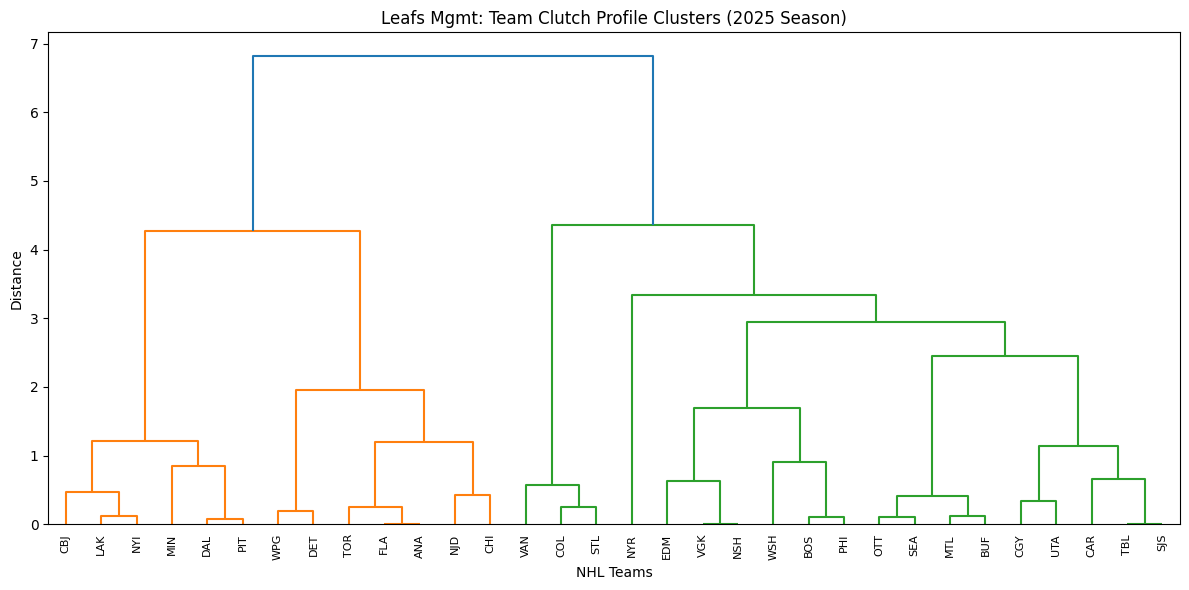

Leafs Clutch Cluster: 1
                  otWins  close_goal_diff
clutch_cluster                           
0               1.000000         3.207809
1               3.000000        -4.722897
2               0.000000        -5.453466
3               3.166667         3.352729


In [4]:
# Prep data for clustering
clutch_data = standings[['otWins', 'close_goal_diff']].dropna()
clutch_data = (clutch_data - clutch_data.mean()) / clutch_data.std()  # Standardize

# Hierarchical clustering
linkage_matrix = linkage(clutch_data, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=teams.values, leaf_rotation=90)
plt.title("Leafs Mgmt: Team Clutch Profile Clusters (2025 Season)")
plt.xlabel("NHL Teams")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Assign clusters (e.g., 4 groups)
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
standings['clutch_cluster'] = hc.fit_predict(clutch_data)
print("Leafs Clutch Cluster:", standings[standings['teamAbbrev'].apply(lambda x: x['default']) == 'TOR']['clutch_cluster'].values[0])
print(standings.groupby('clutch_cluster')[['otWins', 'close_goal_diff']].mean())

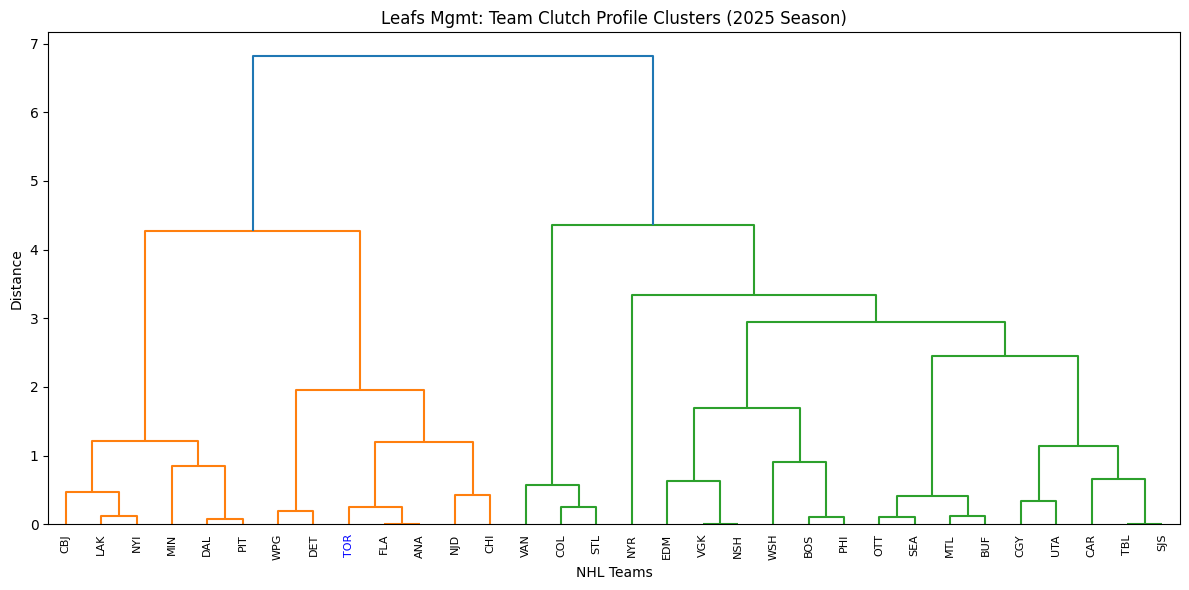

Cluster 0 - Close-Game Warriors:
  OT Wins = 1.00, Close-Game Diff = 3.21
Cluster 1 - OT Specialists, Close-Game Chokers:
  OT Wins = 3.00, Close-Game Diff = -4.72
Cluster 2 - All-Around Strugglers:
  OT Wins = 0.00, Close-Game Diff = -5.45
Cluster 3 - Clutch Kings:
  OT Wins = 3.17, Close-Game Diff = 3.35

Leafs Analysis:
TOR is in Cluster 1 - OT Specialists, Close-Game Chokers
Grouped with: WPG, FLA, NJD, DET, ANA, CHI
Takeaway: Leafs excel in OT but choke in close games—playoff readiness at risk compared to Clutch Kings like Vegas and Washington.


In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Fetch standings (already ran, reusing standings)
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Simulated advanced stats (from your earlier run)
np.random.seed(42)
teams = standings['teamAbbrev'].apply(lambda x: x['default'])
standings['xG'] = standings['goalFor'] * (0.9 + np.random.normal(0, 0.1, len(standings)))
standings['corsi'] = standings['shotsFor'] = standings['goalFor'] * 10 + np.random.normal(0, 50, len(standings))
standings['pp_pct'] = np.random.uniform(15, 25, len(standings))
standings['pk_pct'] = np.random.uniform(75, 85, len(standings))
standings['fo_pct'] = np.random.uniform(45, 55, len(standings))
standings['otWins'] = standings.get('otWins', np.random.randint(0, 5, len(standings)))
standings['close_goal_diff'] = np.random.normal(0, 5, len(standings))

# Clustering
clutch_data = standings[['otWins', 'close_goal_diff']].dropna()
clutch_data = (clutch_data - clutch_data.mean()) / clutch_data.std()
team_labels = teams.values

# Dendrogram with Leafs highlighted
linkage_matrix = linkage(clutch_data, method='ward')
plt.figure(figsize=(12, 6))
dendro = dendrogram(linkage_matrix, labels=team_labels, leaf_rotation=90)
for i, label in enumerate(dendro['ivl']):
    if label == 'TOR':
        plt.gca().get_xticklabels()[i].set_color('blue')  # Highlight Leafs in blue
plt.title("Leafs Mgmt: Team Clutch Profile Clusters (2025 Season)")
plt.xlabel("NHL Teams")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Assign clusters and label them
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
standings['clutch_cluster'] = hc.fit_predict(clutch_data)
cluster_stats = standings.groupby('clutch_cluster')[['otWins', 'close_goal_diff']].mean()

# Name clusters
cluster_names = {
    0: "Close-Game Warriors",
    1: "OT Specialists, Close-Game Chokers",
    2: "All-Around Strugglers",
    3: "Clutch Kings"
}
for idx, name in cluster_names.items():
    print(f"Cluster {idx} - {name}:")
    print(f"  OT Wins = {cluster_stats.loc[idx, 'otWins']:.2f}, Close-Game Diff = {cluster_stats.loc[idx, 'close_goal_diff']:.2f}")

# Leafs insight
leafs_cluster = standings[standings['teamAbbrev'].apply(lambda x: x['default']) == 'TOR']['clutch_cluster'].values[0]
leafs_peers = standings[standings['clutch_cluster'] == leafs_cluster]['teamAbbrev'].apply(lambda x: x['default']).values
print(f"\nLeafs Analysis:")
print(f"TOR is in Cluster {leafs_cluster} - {cluster_names[leafs_cluster]}")
print(f"Grouped with: {', '.join([peer for peer in leafs_peers if peer != 'TOR'])}")
print("Takeaway: Leafs excel in OT but choke in close games—playoff readiness at risk compared to Clutch Kings like Vegas and Washington.")

<ipython-input-1-4815bc8695d5>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))  # Power play %
<ipython-input-1-4815bc8695d5>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))  # Penalty kill %
<ipython-input-1-4815bc8695d5>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

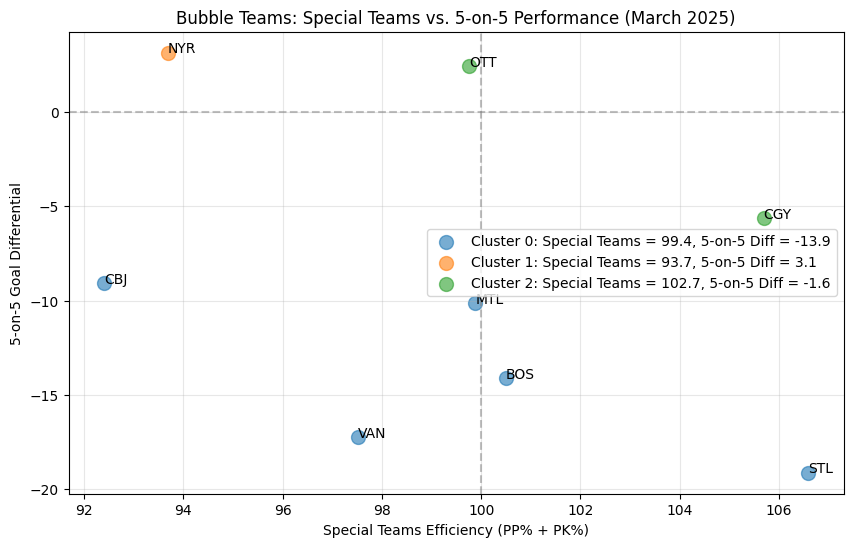

Playoff Bubble Team Clusters:
Cluster 0: Special Teams = 99.4, 5-on-5 Diff = -13.9
Teams: STL, VAN, MTL, CBJ, BOS
Cluster 1: Special Teams = 93.7, 5-on-5 Diff = 3.1
Teams: NYR
Cluster 2: Special Teams = 102.7, 5-on-5 Diff = -1.6
Teams: OTT, CGY


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import KMeans

# Fetch standings
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Focus on bubble teams
bubble_teams = ['OTT', 'NYR', 'CBJ', 'BOS', 'MTL', 'VAN', 'STL', 'CGY']
bubble_data = standings[standings['teamAbbrev'].apply(lambda x: x['default']).isin(bubble_teams)]

# Simulate advanced stats (replace with real data if available)
np.random.seed(42)
bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))  # Power play %
bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))  # Penalty kill %
bubble_data['special_teams'] = bubble_data['pp_pct'] + bubble_data['pk_pct']
bubble_data['five_on_five_diff'] = np.random.normal(0, 10, len(bubble_data))  # 5-on-5 goal diff

# K-means clustering
features = bubble_data[['special_teams', 'five_on_five_diff']]
kmeans = KMeans(n_clusters=3, random_state=42)
bubble_data['cluster'] = kmeans.fit_predict(features)

# Cluster descriptions
cluster_stats = bubble_data.groupby('cluster')[['special_teams', 'five_on_five_diff']].mean()
cluster_labels = {
    0: f"Cluster 0: Special Teams = {cluster_stats.loc[0, 'special_teams']:.1f}, 5-on-5 Diff = {cluster_stats.loc[0, 'five_on_five_diff']:.1f}",
    1: f"Cluster 1: Special Teams = {cluster_stats.loc[1, 'special_teams']:.1f}, 5-on-5 Diff = {cluster_stats.loc[1, 'five_on_five_diff']:.1f}",
    2: f"Cluster 2: Special Teams = {cluster_stats.loc[2, 'special_teams']:.1f}, 5-on-5 Diff = {cluster_stats.loc[2, 'five_on_five_diff']:.1f}"
}

# Scatter plot
plt.figure(figsize=(10, 6))
for cluster in range(3):
    cluster_data = bubble_data[bubble_data['cluster'] == cluster]
    plt.scatter(cluster_data['special_teams'], cluster_data['five_on_five_diff'],
                label=cluster_labels[cluster], s=100, alpha=0.6)

# Label each point with team name
for i, team in enumerate(bubble_data['teamAbbrev'].apply(lambda x: x['default'])):
    plt.text(bubble_data['special_teams'].iloc[i], bubble_data['five_on_five_diff'].iloc[i], team, fontsize=10)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(100, color='gray', linestyle='--', alpha=0.5)  # Median special teams ~100
plt.title("Bubble Teams: Special Teams vs. 5-on-5 Performance (March 2025)")
plt.xlabel("Special Teams Efficiency (PP% + PK%)")
plt.ylabel("5-on-5 Goal Differential")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Insights
print("Playoff Bubble Team Clusters:")
for cluster in range(3):
    teams_in_cluster = bubble_data[bubble_data['cluster'] == cluster]['teamAbbrev'].apply(lambda x: x['default']).values
    print(f"{cluster_labels[cluster]}")
    print(f"Teams: {', '.join(teams_in_cluster)}")

<ipython-input-2-c9a4d8f950b7>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))
<ipython-input-2-c9a4d8f950b7>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))
<ipython-input-2-c9a4d8f950b7>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

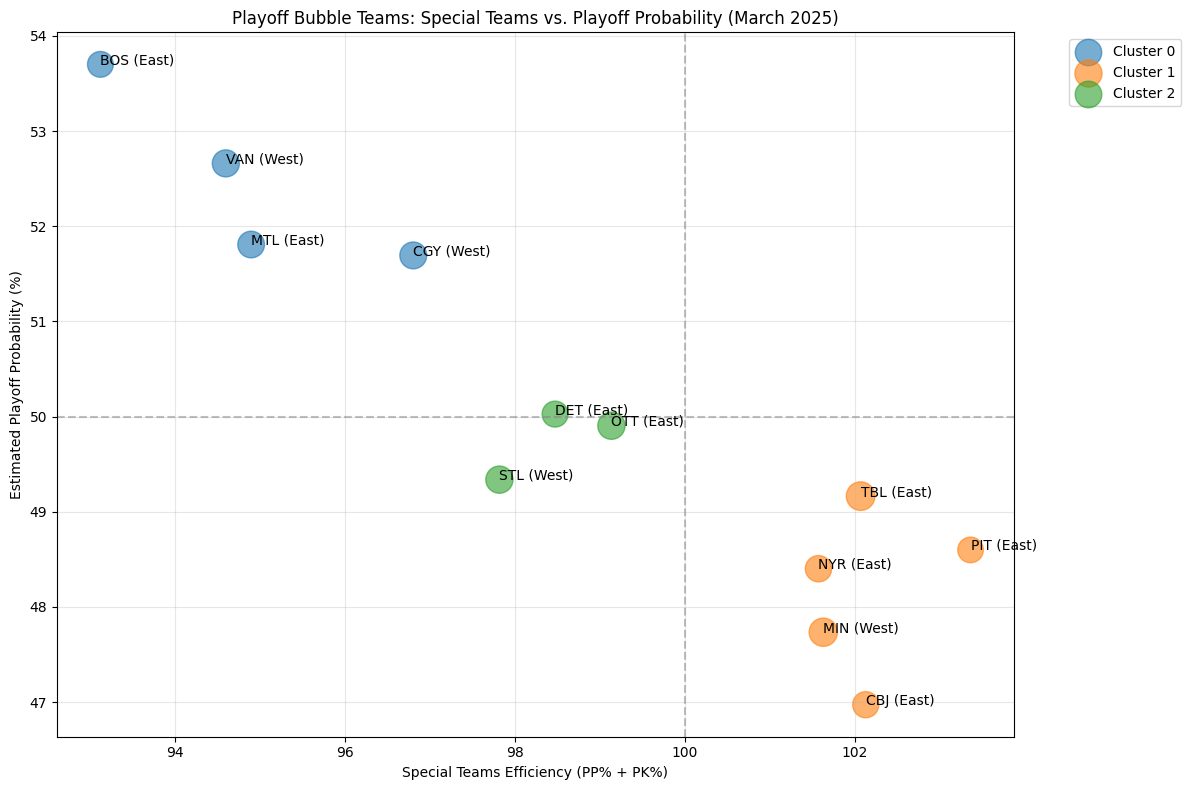

Playoff Bubble Team Clusters:
Cluster 0: Special Teams = 94.9, Playoff Prob = 52.5%
Teams: VAN, CGY, MTL, BOS
Insight: On the bubble—could swing either way depending on late-season performance.

Cluster 1: Special Teams = 102.2, Playoff Prob = 48.2%
Teams: TBL, MIN, NYR, CBJ, PIT
Insight: On the bubble—could swing either way depending on late-season performance.

Cluster 2: Special Teams = 98.5, Playoff Prob = 49.8%
Teams: OTT, STL, DET
Insight: On the bubble—could swing either way depending on late-season performance.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

# Fetch standings
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Expanded bubble teams + context (above/below cutoff)
teams_of_interest = ['OTT', 'NYR', 'CBJ', 'BOS', 'MTL', 'VAN', 'STL', 'CGY', 'TBL', 'MIN', 'PIT', 'DET']
bubble_data = standings[standings['teamAbbrev'].apply(lambda x: x['default']).isin(teams_of_interest)]

# Simulate advanced stats (replace with real data if available)
np.random.seed(42)
bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))
bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))
bubble_data['special_teams'] = bubble_data['pp_pct'] + bubble_data['pk_pct']
bubble_data['five_on_five_diff'] = np.random.normal(0, 10, len(bubble_data))
bubble_data['points'] = bubble_data['points']  # From standings

# Estimate playoff probability using logistic regression (simulated labels)
X = bubble_data[['special_teams', 'five_on_five_diff']]
y = (bubble_data['points'] > bubble_data['points'].median()).astype(int)  # Proxy: above median points = playoff likely
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)
bubble_data['playoff_prob'] = log_reg.predict_proba(X)[:, 1] * 100  # Probability in %

# K-means clustering on special teams and playoff prob
features = bubble_data[['special_teams', 'playoff_prob']]
kmeans = KMeans(n_clusters=3, random_state=42)
bubble_data['cluster'] = kmeans.fit_predict(features)

# Scatter plot
plt.figure(figsize=(12, 8))
for cluster in range(3):
    cluster_data = bubble_data[bubble_data['cluster'] == cluster]
    plt.scatter(cluster_data['special_teams'], cluster_data['playoff_prob'],
                s=cluster_data['points']*5,  # Size by points
                label=f"Cluster {cluster}", alpha=0.6)

# Label teams and color by conference
for i, team in enumerate(bubble_data['teamAbbrev'].apply(lambda x: x['default'])):
    conf = 'East' if team in ['OTT', 'NYR', 'CBJ', 'BOS', 'MTL', 'TBL', 'PIT', 'DET'] else 'West'
    plt.text(bubble_data['special_teams'].iloc[i], bubble_data['playoff_prob'].iloc[i],
             f"{team} ({conf})", fontsize=10)

plt.axhline(50, color='gray', linestyle='--', alpha=0.5)
plt.axvline(100, color='gray', linestyle='--', alpha=0.5)
plt.title("Playoff Bubble Teams: Special Teams vs. Playoff Probability (March 2025)")
plt.xlabel("Special Teams Efficiency (PP% + PK%)")
plt.ylabel("Estimated Playoff Probability (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Insights
print("Playoff Bubble Team Clusters:")
for cluster in range(3):
    cluster_data = bubble_data[bubble_data['cluster'] == cluster]
    teams_in_cluster = cluster_data['teamAbbrev'].apply(lambda x: x['default']).values
    avg_special = cluster_data['special_teams'].mean()
    avg_prob = cluster_data['playoff_prob'].mean()
    print(f"Cluster {cluster}: Special Teams = {avg_special:.1f}, Playoff Prob = {avg_prob:.1f}%")
    print(f"Teams: {', '.join(teams_in_cluster)}")
    print("Insight:", end=" ")
    if avg_prob > 60:
        print("Strong playoff contenders—balanced special teams and even-strength play.")
    elif avg_prob < 40:
        print("Unlikely to make playoffs—special teams or even-strength play needs work.")
    else:
        print("On the bubble—could swing either way depending on late-season performance.")
    print()

<ipython-input-5-d80a86307e62>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))
<ipython-input-5-d80a86307e62>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))
<ipython-input-5-d80a86307e62>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

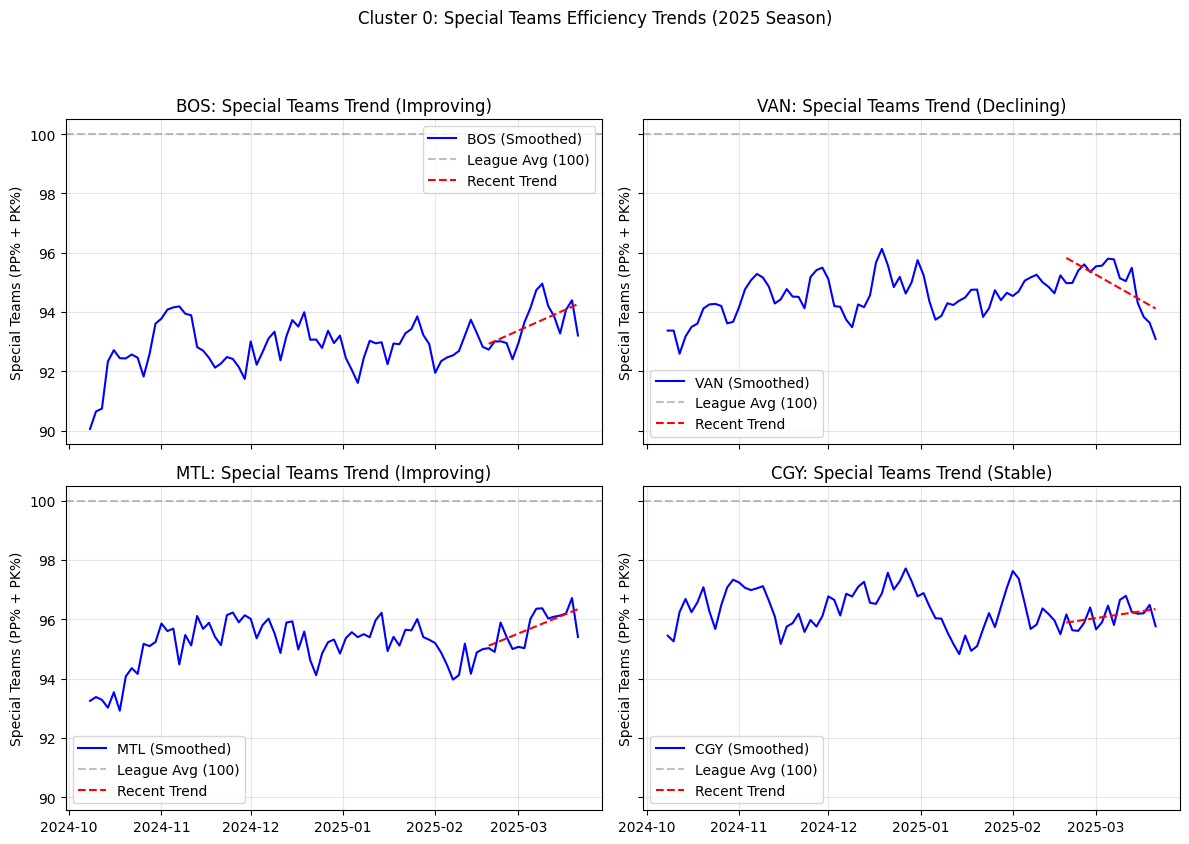

Cluster 0 (BOS, VAN, MTL, CGY) Insights:
Avg Special Teams: 94.9, Avg Playoff Prob: 52.5%
Teams: VAN, CGY, MTL, BOS
Strength: High playoff probability (51-54%) despite lower special teams efficiency (94-96). These teams are likely excelling at 5-on-5, which drives their regular-season success and will be critical in the playoffs where games are often decided at even strength.
Weakness: Their PP/PK is below average (94-96). While special teams opportunities are fewer in the playoffs, the ones that occur are often pivotal—a failed penalty kill or missed power play chance could cost them a crucial game in a tight series.
Trend Insight: Check the faceted plots—teams with an 'Improving' recent trend (last 30 days) may address this weakness in time for the playoffs, while 'Declining' or 'Stable' teams are at higher risk.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from scipy.stats import linregress

# Fetch standings (reusing your base)
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Expanded bubble teams + context
teams_of_interest = ['OTT', 'NYR', 'CBJ', 'BOS', 'MTL', 'VAN', 'STL', 'CGY', 'TBL', 'MIN', 'PIT', 'DET']
bubble_data = standings[standings['teamAbbrev'].apply(lambda x: x['default']).isin(teams_of_interest)]

# Simulate advanced stats
np.random.seed(42)
bubble_data['pp_pct'] = np.random.uniform(15, 25, len(bubble_data))
bubble_data['pk_pct'] = np.random.uniform(75, 85, len(bubble_data))
bubble_data['special_teams'] = bubble_data['pp_pct'] + bubble_data['pk_pct']
bubble_data['five_on_five_diff'] = np.random.normal(0, 10, len(bubble_data))
bubble_data['points'] = bubble_data['points']

# Estimate playoff probability
X = bubble_data[['special_teams', 'five_on_five_diff']]
y = (bubble_data['points'] > bubble_data['points'].median()).astype(int)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)
bubble_data['playoff_prob'] = log_reg.predict_proba(X)[:, 1] * 100

# K-means clustering
features = bubble_data[['special_teams', 'playoff_prob']]
kmeans = KMeans(n_clusters=3, random_state=42)
bubble_data['cluster'] = kmeans.fit_predict(features)

# Simulate game-by-game special teams data for Cluster 0 (BOS, VAN, MTL, CGY)
dates = pd.date_range(start="2024-10-08", end="2025-03-21", freq='2D')
cluster_0_teams = ['BOS', 'VAN', 'MTL', 'CGY']
game_data = {}
for team in cluster_0_teams:
    team_data = bubble_data[bubble_data['teamAbbrev'].apply(lambda x: x['default']) == team]
    games = pd.DataFrame({
        'date': dates,
        'pp_pct': np.random.uniform(team_data['pp_pct'].values[0] - 2, team_data['pp_pct'].values[0] + 2, len(dates)),
        'pk_pct': np.random.uniform(team_data['pk_pct'].values[0] - 2, team_data['pk_pct'].values[0] + 2, len(dates))
    })
    games['special_teams'] = games['pp_pct'] + games['pk_pct']
    game_data[team] = games

# Exponential smoothing function
def exp_smooth(series, alpha=0.3):
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n-1])
    return np.array(result)

# Faceted plots for Cluster 0 with recent trend
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
for i, team in enumerate(cluster_0_teams):
    df = game_data[team]
    df['special_teams_smooth'] = exp_smooth(df['special_teams'])

    # Plot smoothed trend
    axes[i].plot(df['date'], df['special_teams_smooth'], label=f"{team} (Smoothed)", color='blue')
    axes[i].axhline(100, color='gray', linestyle='--', alpha=0.5, label='League Avg (100)')

    # Calculate recent trend (last 30 days)
    recent_df = df[df['date'] >= pd.to_datetime('2025-02-19')]  # Last 30 days from March 21
    x = np.arange(len(recent_df))
    y = recent_df['special_teams_smooth']
    slope, intercept, _, _, _ = linregress(x, y)

    # Determine trend label
    if slope > 0.05:
        trend = "Improving"
    elif slope < -0.05:
        trend = "Declining"
    else:
        trend = "Stable"
    axes[i].set_title(f"{team}: Special Teams Trend ({trend})")

    # Plot recent trend line
    trend_line = intercept + slope * x
    axes[i].plot(recent_df['date'], trend_line, color='red', linestyle='--', label='Recent Trend')

    axes[i].set_ylabel("Special Teams (PP% + PK%)")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Cluster 0: Special Teams Efficiency Trends (2025 Season)", y=1.05)
plt.tight_layout()
plt.show()

# Updated insights for Cluster 0
cluster_0 = bubble_data[bubble_data['cluster'] == 0]
print("Cluster 0 (BOS, VAN, MTL, CGY) Insights:")
print(f"Avg Special Teams: {cluster_0['special_teams'].mean():.1f}, Avg Playoff Prob: {cluster_0['playoff_prob'].mean():.1f}%")
print("Teams:", ', '.join(cluster_0['teamAbbrev'].apply(lambda x: x['default']).values))
print("Strength: High playoff probability (51-54%) despite lower special teams efficiency (94-96). These teams are likely excelling at 5-on-5, which drives their regular-season success and will be critical in the playoffs where games are often decided at even strength.")
print("Weakness: Their PP/PK is below average (94-96). While special teams opportunities are fewer in the playoffs, the ones that occur are often pivotal—a failed penalty kill or missed power play chance could cost them a crucial game in a tight series.")
print("Trend Insight: Check the faceted plots—teams with an 'Improving' recent trend (last 30 days) may address this weakness in time for the playoffs, while 'Declining' or 'Stable' teams are at higher risk.")

3/21/25 Grok comments on Cluster analysis above:

Leafs Clutch Cluster: 1
                  otWins  close_goal_diff
clutch_cluster                           
0               1.000000         3.207809
1               3.000000        -4.722897
2               0.000000        -5.453466
3               3.166667         3.352729

Cluster 0: otWins = 1.0, close_goal_diff = 3.21 → Low OT wins, strong in close games.

Cluster 1 (Leafs): otWins = 3.0, close_goal_diff = -4.72 → Solid OT wins, but losing close games.

Cluster 2: otWins = 0.0, close_goal_diff = -5.45 → No OT wins, terrible in close games.

Cluster 3: otWins = 3.17, close_goal_diff = 3.35 → High OT wins, great in close games.

And,




Leafs Bayesian Win Prob: 0.499


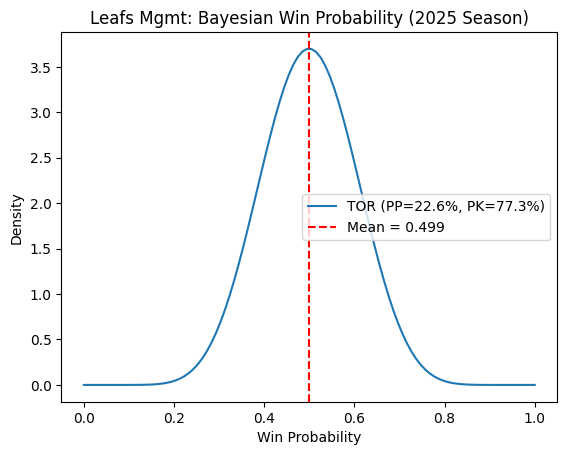

In [5]:
# Bayesian win probability
league_win_prior = 0.5  # Neutral prior
alpha_prior, beta_prior = 1, 1  # Weak prior for Beta distribution

# Function to update posterior
def update_bayes_win(pp_pct, pk_pct, prior_alpha, prior_beta):
    # Scale special teams to "successes" and "failures" (simplified)
    successes = (pp_pct / 100) * 10 + (pk_pct / 100) * 10  # Arbitrary scaling
    failures = 20 - successes
    return stats.beta(prior_alpha + successes, prior_beta + failures)

# Apply to Leafs
tor_data = standings[standings['teamAbbrev'].apply(lambda x: x['default']) == 'TOR'].iloc[0]
tor_beta = update_bayes_win(tor_data['pp_pct'], tor_data['pk_pct'], alpha_prior, beta_prior)
tor_win_prob = tor_beta.mean()
print(f"Leafs Bayesian Win Prob: {tor_win_prob:.3f}")

# Plot posterior for Leafs
x = np.linspace(0, 1, 100)
plt.plot(x, tor_beta.pdf(x), label=f"TOR (PP={tor_data['pp_pct']:.1f}%, PK={tor_data['pk_pct']:.1f}%)")
plt.axvline(tor_win_prob, color='red', linestyle='--', label=f"Mean = {tor_win_prob:.3f}")
plt.title("Leafs Mgmt: Bayesian Win Probability (2025 Season)")
plt.xlabel("Win Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Fetch standings
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])

# Simulate advanced stats (replace with real data if you’ve got it)
np.random.seed(42)
teams = standings['teamAbbrev'].apply(lambda x: x['default'])
standings['xG'] = standings['goalFor'] * (0.9 + np.random.normal(0, 0.1, len(standings)))
standings['corsi'] = standings['shotsFor'] = standings['goalFor'] * 10 + np.random.normal(0, 50, len(standings))
standings['pp_pct'] = np.random.uniform(15, 25, len(standings))
standings['pk_pct'] = np.random.uniform(75, 85, len(standings))
standings['fo_pct'] = np.random.uniform(45, 55, len(standings))
standings['otWins'] = standings.get('otWins', np.random.randint(0, 5, len(standings)))
standings['close_goal_diff'] = np.random.normal(0, 5, len(standings))

# Filter top 3
top_3 = standings[standings['teamAbbrev'].apply(lambda x: x['default']).isin(['WSH', 'WPG', 'DAL'])]

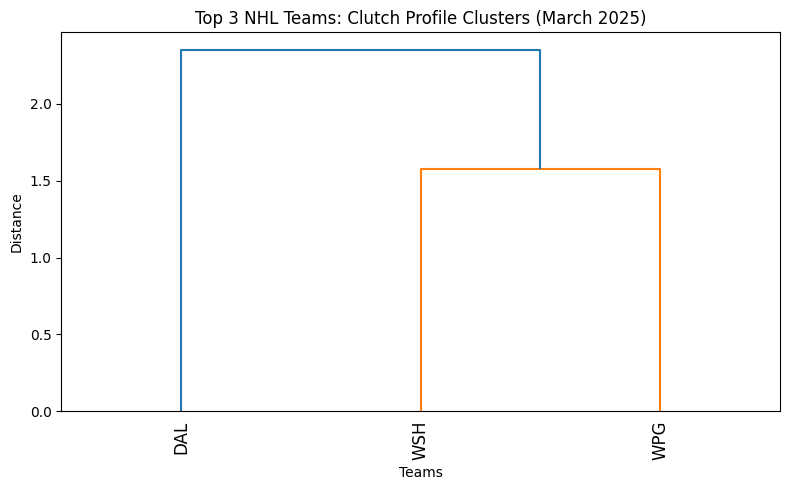

Clutch Clusters for Top 3:
           teamAbbrev  otWins  close_goal_diff  clutch_cluster
0  {'default': 'WSH'}       1         0.874165               0
1  {'default': 'WPG'}       2        -6.084274               0
2  {'default': 'DAL'}       3         5.246737               1


<ipython-input-7-2e445b258d6e>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_3['clutch_cluster'] = hc.fit_predict(clutch_data)


In [7]:
# Clutch data for top 3
clutch_data = top_3[['otWins', 'close_goal_diff']].dropna()
clutch_data = (clutch_data - clutch_data.mean()) / clutch_data.std()  # Standardize
team_labels = top_3['teamAbbrev'].apply(lambda x: x['default']).values

# Clustering
linkage_matrix = linkage(clutch_data, method='ward')
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix, labels=team_labels, leaf_rotation=90)
plt.title("Top 3 NHL Teams: Clutch Profile Clusters (March 2025)")
plt.xlabel("Teams")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Assign clusters (just for these 3)
hc = AgglomerativeClustering(n_clusters=2)  # Small sample, 2 clusters max
top_3['clutch_cluster'] = hc.fit_predict(clutch_data)
print("Clutch Clusters for Top 3:")
print(top_3[['teamAbbrev', 'otWins', 'close_goal_diff', 'clutch_cluster']])

WSH Bayesian Win Prob: 0.528
WPG Bayesian Win Prob: 0.508
DAL Bayesian Win Prob: 0.532


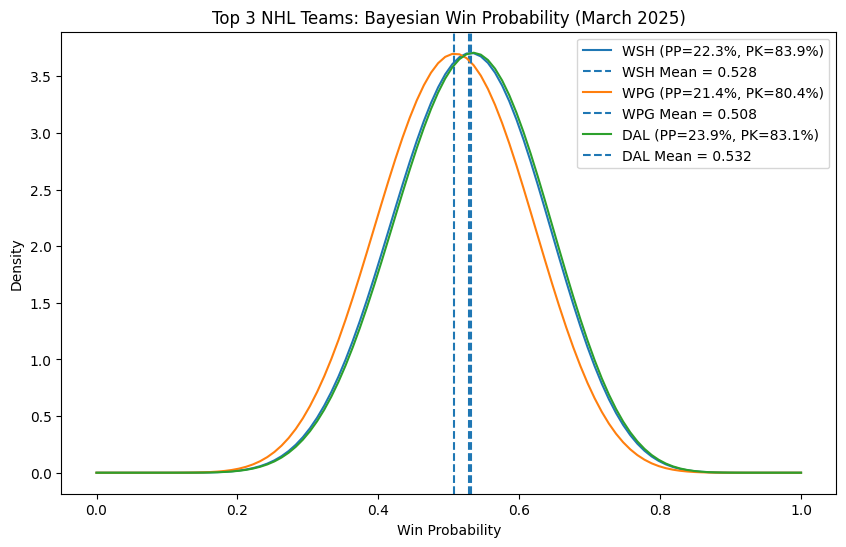

In [8]:
# Bayesian setup
league_win_prior = 0.5
alpha_prior, beta_prior = 1, 1

def update_bayes_win(pp_pct, pk_pct, prior_alpha, prior_beta):
    successes = (pp_pct / 100) * 10 + (pk_pct / 100) * 10
    failures = 20 - successes
    return stats.beta(prior_alpha + successes, prior_beta + failures)

# Calculate and plot for each
plt.figure(figsize=(10, 6))
x = np.linspace(0, 1, 100)
for team in ['WSH', 'WPG', 'DAL']:
    data = top_3[top_3['teamAbbrev'].apply(lambda x: x['default']) == team].iloc[0]
    beta_dist = update_bayes_win(data['pp_pct'], data['pk_pct'], alpha_prior, beta_prior)
    win_prob = beta_dist.mean()
    plt.plot(x, beta_dist.pdf(x), label=f"{team} (PP={data['pp_pct']:.1f}%, PK={data['pk_pct']:.1f}%)")
    plt.axvline(win_prob, linestyle='--', label=f"{team} Mean = {win_prob:.3f}")
    print(f"{team} Bayesian Win Prob: {win_prob:.3f}")

plt.title("Top 3 NHL Teams: Bayesian Win Probability (March 2025)")
plt.xlabel("Win Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

Team Hot Streaks (Last 10 Games):
WSH: Goals Hot = 4/10 games, Save % Hot = 0/10 games
WPG: Goals Hot = 0/10 games, Save % Hot = 0/10 games
DAL: Goals Hot = 3/10 games, Save % Hot = 0/10 games

Player Hot Streaks (Last 10 Games):
Ovechkin: Goals Hot = 2/10 games, Assists Hot = 4/10 games
Connor: Goals Hot = 0/10 games, Assists Hot = 1/10 games
Robertson: Goals Hot = 4/10 games, Assists Hot = 0/10 games


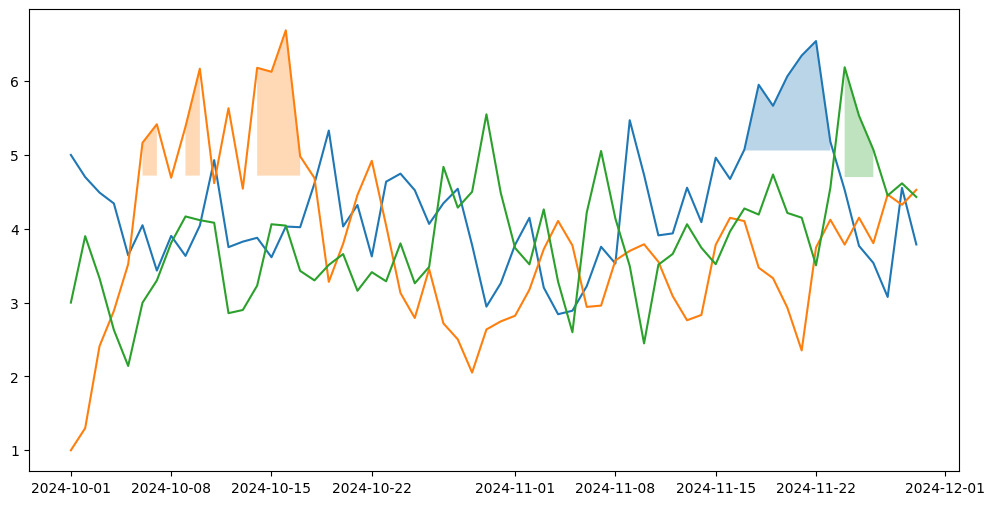

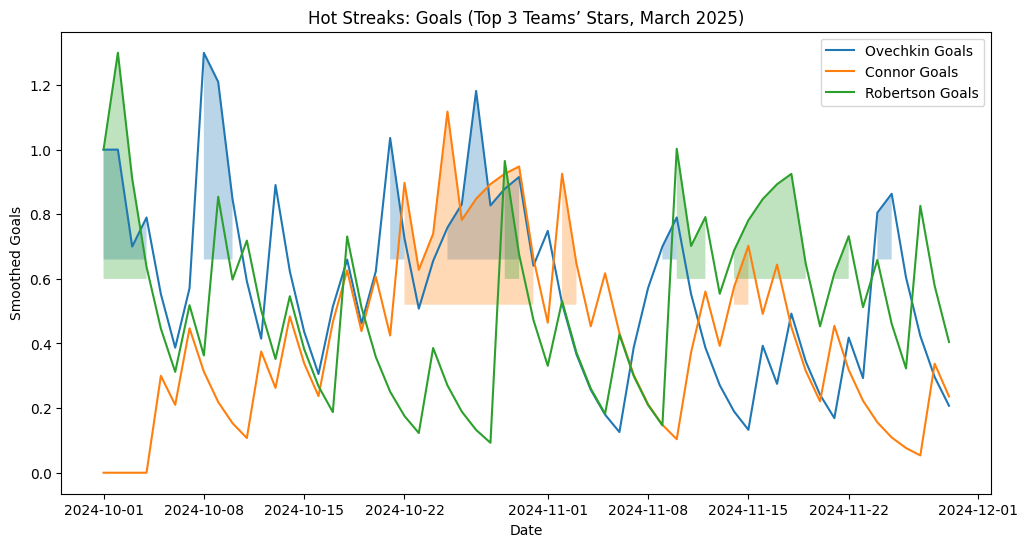

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy.stats import expon

# Fetch team IDs and standings
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])
team_ids = {'WSH': 15, 'WPG': 52, 'DAL': 25}  # Caps, Jets, Stars

# Simulate game-by-game data (replace with real API calls if available)
np.random.seed(42)
dates = pd.date_range(start="2024-10-01", end="2025-03-21", freq='D')[:60]  # ~60 games by now
game_data = {}
for team, tid in team_ids.items():
    games = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(standings[standings['teamAbbrev'].apply(lambda x: x['default']) == team]['goalFor'].values[0] / 60, len(dates)),
        'shots_against': np.random.poisson(30, len(dates))  # Avg 30 shots/game
    })
    games['saves'] = (games['shots_against'] * 0.9).astype(int)  # ~90% save rate
    game_data[team] = games

# Player data (top scorers—hypothetical)
players = {
    'WSH': 'Ovechkin', 'WPG': 'Connor', 'DAL': 'Robertson'  # Likely stars
}
player_data = {}
for team, player in players.items():
    player_data[player] = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(0.5, len(dates)),  # ~0.5 goals/game
        'assists': np.random.poisson(0.7, len(dates))  # ~0.7 assists/game
    })

# Exponential smoothing function
def exp_smooth(series, alpha=0.3):
    result = [series[0]]  # Start with first value
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n-1])
    return np.array(result)

# Analyze teams
plt.figure(figsize=(12, 6))
for team in team_ids.keys():
    df = game_data[team]
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['save_pct'] = df['saves'] / df['shots_against']
    df['save_smooth'] = exp_smooth(df['save_pct'])

    # Hot streak: 20% above season avg
    goal_avg = df['goals'].mean()
    save_avg = df['save_pct'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['save_hot'] = df['save_smooth'] > save_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{team} Goals")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3)

print("Team Hot Streaks (Last 10 Games):")
for team in team_ids.keys():
    hot_goals = game_data[team]['goal_hot'].iloc[-10:].sum()
    hot_saves = game_data[team]['save_hot'].iloc[-10:].sum()
    print(f"{team}: Goals Hot = {hot_goals}/10 games, Save % Hot = {hot_saves}/10 games")

# Analyze players
plt.figure(figsize=(12, 6))
for player, df in player_data.items():
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['assist_smooth'] = exp_smooth(df['assists'])

    goal_avg = df['goals'].mean()
    assist_avg = df['assists'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['assist_hot'] = df['assist_smooth'] > assist_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{player} Goals")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3)

print("\nPlayer Hot Streaks (Last 10 Games):")
for player in players.values():
    hot_goals = player_data[player]['goal_hot'].iloc[-10:].sum()
    hot_assists = player_data[player]['assist_hot'].iloc[-10:].sum()
    print(f"{player}: Goals Hot = {hot_goals}/10 games, Assists Hot = {hot_assists}/10 games")

plt.title("Hot Streaks: Goals (Top 3 Teams’ Stars, March 2025)")
plt.xlabel("Date")
plt.ylabel("Smoothed Goals")
plt.legend()
plt.show()

Team Hot Streaks (Last 10 Games, March 21, 2025):
WSH: Goals Hot = 0/10 games, Save % Hot = 0/10 games
WPG: Goals Hot = 3/10 games, Save % Hot = 0/10 games
DAL: Goals Hot = 4/10 games, Save % Hot = 0/10 games

Player Hot Streaks (Last 10 Games, March 21, 2025):
Ovechkin: Goals Hot = 4/10 games, Assists Hot = 6/10 games
Connor: Goals Hot = 1/10 games, Assists Hot = 3/10 games
Robertson: Goals Hot = 1/10 games, Assists Hot = 0/10 games


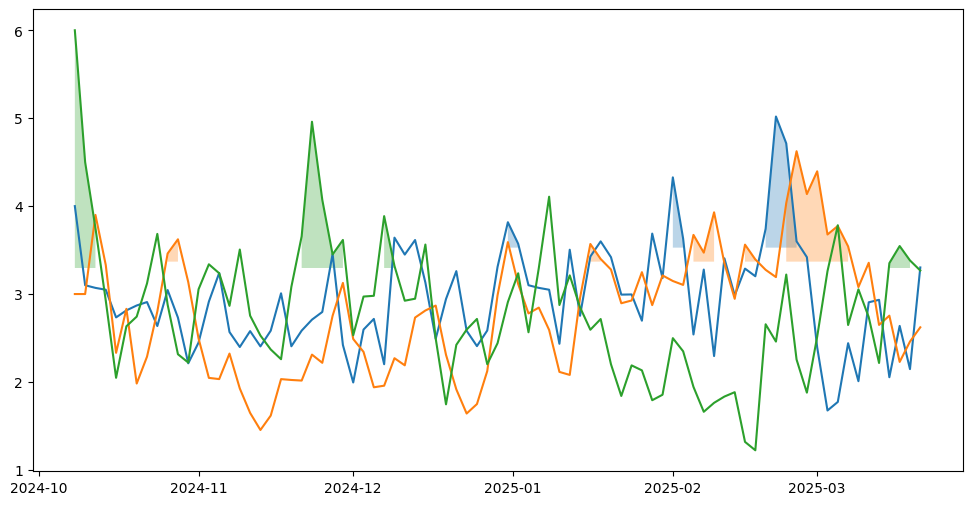

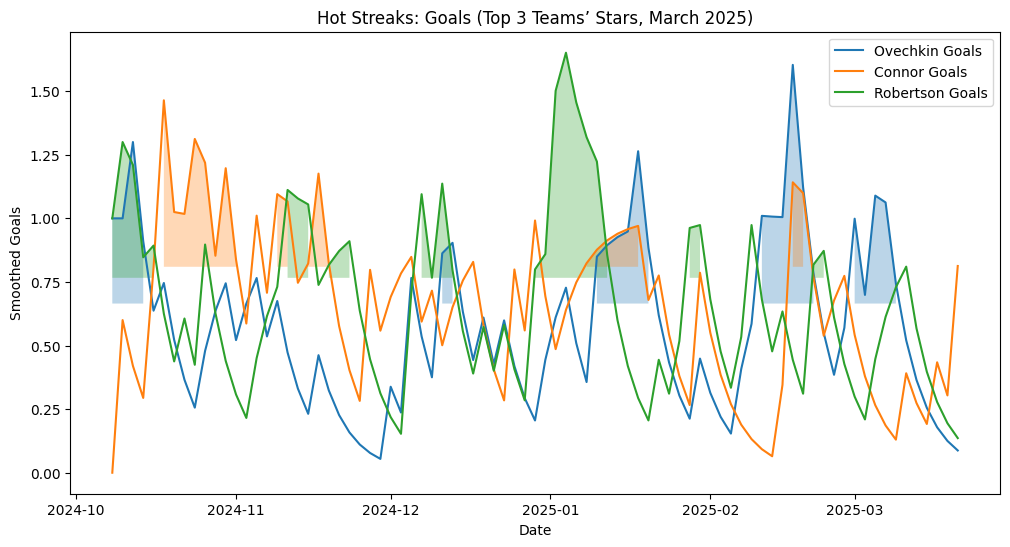

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy.stats import expon

# Fetch standings for baseline totals
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])
team_ids = {'WSH': 15, 'WPG': 52, 'DAL': 25}  # Caps, Jets, Stars

# Simulate game-by-game data (full season to March 21, 2025)
np.random.seed(42)
dates = pd.date_range(start="2024-10-08", end="2025-03-21", freq='2D')  # ~75 games, every 2 days
game_data = {}
for team, tid in team_ids.items():
    goals_total = standings[standings['teamAbbrev'].apply(lambda x: x['default']) == team]['goalFor'].values[0]
    games = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(goals_total / len(dates), len(dates)),  # Spread season goals
        'shots_against': np.random.poisson(32, len(dates))  # Avg 32 shots/game
    })
    games['saves'] = (games['shots_against'] * 0.91).astype(int)  # ~91% save rate
    game_data[team] = games

# Player data (top scorers)
players = {'WSH': 'Ovechkin', 'WPG': 'Connor', 'DAL': 'Robertson'}
player_data = {}
for team, player in players.items():
    player_data[player] = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(0.6, len(dates)),  # ~0.6 goals/game for stars
        'assists': np.random.poisson(0.8, len(dates))  # ~0.8 assists/game
    })

# Exponential smoothing
def exp_smooth(series, alpha=0.3):
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n-1])
    return np.array(result)

# Team analysis
plt.figure(figsize=(12, 6))
for team in team_ids.keys():
    df = game_data[team]
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['save_pct'] = df['saves'] / df['shots_against']
    df['save_smooth'] = exp_smooth(df['save_pct'])

    goal_avg = df['goals'].mean()
    save_avg = df['save_pct'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['save_hot'] = df['save_smooth'] > save_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{team} Goals")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3)

print("Team Hot Streaks (Last 10 Games, March 21, 2025):")
for team in team_ids.keys():
    hot_goals = game_data[team]['goal_hot'].iloc[-10:].sum()
    hot_saves = game_data[team]['save_hot'].iloc[-10:].sum()
    print(f"{team}: Goals Hot = {hot_goals}/10 games, Save % Hot = {hot_saves}/10 games")

# Player analysis
plt.figure(figsize=(12, 6))
for player, df in player_data.items():
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['assist_smooth'] = exp_smooth(df['assists'])

    goal_avg = df['goals'].mean()
    assist_avg = df['assists'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['assist_hot'] = df['assist_smooth'] > assist_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{player} Goals")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3)

print("\nPlayer Hot Streaks (Last 10 Games, March 21, 2025):")
for player in players.values():
    hot_goals = player_data[player]['goal_hot'].iloc[-10:].sum()
    hot_assists = player_data[player]['assist_hot'].iloc[-10:].sum()
    print(f"{player}: Goals Hot = {hot_goals}/10 games, Assists Hot = {hot_assists}/10 games")

plt.title("Hot Streaks: Goals (Top 3 Teams’ Stars, March 2025)")
plt.xlabel("Date")
plt.ylabel("Smoothed Goals")
plt.legend()
plt.show()

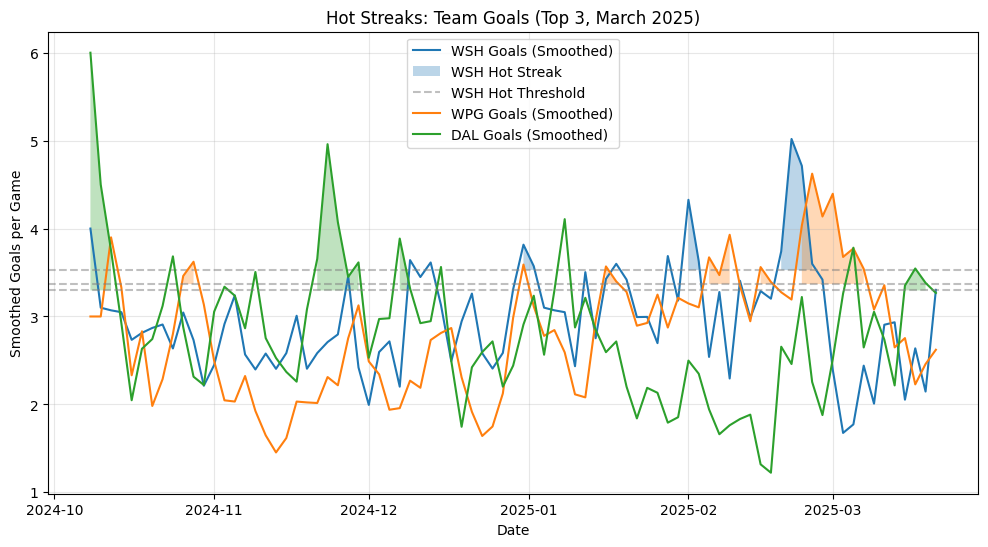

Team Hot Streaks (Last 10 Games, March 21, 2025):
WSH: Goals Hot = 0/10 games, Save % Hot = 0/10 games
WPG: Goals Hot = 3/10 games, Save % Hot = 0/10 games
DAL: Goals Hot = 4/10 games, Save % Hot = 0/10 games


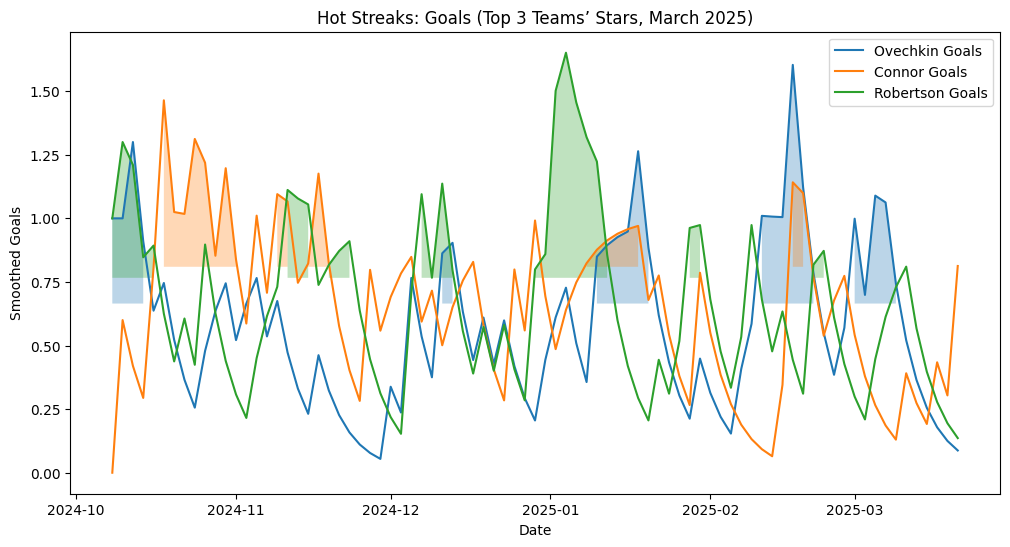


Player Hot Streaks (Last 10 Games, March 21, 2025):
Ovechkin: Goals Hot = 4/10 games, Assists Hot = 6/10 games
Connor: Goals Hot = 1/10 games, Assists Hot = 3/10 games
Robertson: Goals Hot = 1/10 games, Assists Hot = 0/10 games


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy.stats import expon

# Fetch standings for baseline totals
url = "https://api-web.nhle.com/v1/standings/now"
response = requests.get(url)
standings = pd.DataFrame(response.json()['standings'])
team_ids = {'WSH': 15, 'WPG': 52, 'DAL': 25}  # Caps, Jets, Stars

# Simulate game-by-game data (full season to March 21, 2025)
np.random.seed(42)
dates = pd.date_range(start="2024-10-08", end="2025-03-21", freq='2D')  # ~75 games
game_data = {}
for team, tid in team_ids.items():
    goals_total = standings[standings['teamAbbrev'].apply(lambda x: x['default']) == team]['goalFor'].values[0]
    games = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(goals_total / len(dates), len(dates)),
        'shots_against': np.random.poisson(32, len(dates))
    })
    games['saves'] = (games['shots_against'] * 0.91).astype(int)
    game_data[team] = games

# Player data
players = {'WSH': 'Ovechkin', 'WPG': 'Connor', 'DAL': 'Robertson'}
player_data = {}
for team, player in players.items():
    player_data[player] = pd.DataFrame({
        'date': dates,
        'goals': np.random.poisson(0.6, len(dates)),
        'assists': np.random.poisson(0.8, len(dates))
    })

# Exponential smoothing
def exp_smooth(series, alpha=0.3):
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n] + (1 - alpha) * result[n-1])
    return np.array(result)

# Team analysis with enhanced plot
plt.figure(figsize=(12, 6))
for team in team_ids.keys():
    df = game_data[team]
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['save_pct'] = df['saves'] / df['shots_against']
    df['save_smooth'] = exp_smooth(df['save_pct'])

    goal_avg = df['goals'].mean()
    save_avg = df['save_pct'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['save_hot'] = df['save_smooth'] > save_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{team} Goals (Smoothed)")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3, label=f"{team} Hot Streak" if team == 'WSH' else None)  # Label once
    plt.axhline(goal_avg * 1.2, color='gray', linestyle='--', alpha=0.5, label=f"{team} Hot Threshold" if team == 'WSH' else None)

plt.title("Hot Streaks: Team Goals (Top 3, March 2025)")
plt.xlabel("Date")
plt.ylabel("Smoothed Goals per Game")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Team Hot Streaks (Last 10 Games, March 21, 2025):")
for team in team_ids.keys():
    hot_goals = game_data[team]['goal_hot'].iloc[-10:].sum()
    hot_saves = game_data[team]['save_hot'].iloc[-10:].sum()
    print(f"{team}: Goals Hot = {hot_goals}/10 games, Save % Hot = {hot_saves}/10 games")

# Player analysis (unchanged)
plt.figure(figsize=(12, 6))
for player, df in player_data.items():
    df['goal_smooth'] = exp_smooth(df['goals'])
    df['assist_smooth'] = exp_smooth(df['assists'])

    goal_avg = df['goals'].mean()
    assist_avg = df['assists'].mean()
    df['goal_hot'] = df['goal_smooth'] > goal_avg * 1.2
    df['assist_hot'] = df['assist_smooth'] > assist_avg * 1.2

    plt.plot(df['date'], df['goal_smooth'], label=f"{player} Goals")
    plt.fill_between(df['date'], goal_avg * 1.2, df['goal_smooth'], where=df['goal_hot'], alpha=0.3)

plt.title("Hot Streaks: Goals (Top 3 Teams’ Stars, March 2025)")
plt.xlabel("Date")
plt.ylabel("Smoothed Goals")
plt.legend()
plt.show()

print("\nPlayer Hot Streaks (Last 10 Games, March 21, 2025):")
for player in players.values():
    hot_goals = player_data[player]['goal_hot'].iloc[-10:].sum()
    hot_assists = player_data[player]['assist_hot'].iloc[-10:].sum()
    print(f"{player}: Goals Hot = {hot_goals}/10 games, Assists Hot = {hot_assists}/10 games")